## DATA LOADING

In [ ]:
# Install required packages
# pip install pandas numpy scikit-learn nltk googletrans gTTS playsound

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re
from googletrans import Translator
from gtts import gTTS
import os
# from playsound import playsound
# import matplotlib.pyplot as plt
# import seaborn as sns

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')

In [ ]:
# Set paths to dataset files
metadata_path = "/home/muhammad-usman/AI_Project/MovieSummaries/movie.metadata.tsv"
summaries_path = "/home/muhammad-usman/AI_Project/MovieSummaries/plot_summaries.txt"

# Load movie metadata
metadata = pd.read_csv(metadata_path, sep='\t', header=None)
metadata.columns = ['movie_id', 'freebase_id', 'movie_name', 'release_date', 'revenue', 'runtime', 'languages', 'countries', 'genres']
print("Metadata shape:", metadata.shape)

# Load summaries
summaries = pd.read_csv(summaries_path, sep='\t', header=None)
summaries.columns = ['movie_id', 'summary']
print("Summaries shape:", summaries.shape)

# Merge datasets on movie_id
data = pd.merge(metadata[['movie_id', 'movie_name', 'genres']], summaries, on='movie_id')
print("Merged data shape:", data.shape)
data.head()

## DATA Processing

In [ ]:
# Function to preprocess text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens]
    # Join tokens back to text
    return ' '.join(tokens)

# Apply preprocessing to summaries
data['cleaned_summary'] = data['summary'].apply(preprocess_text)
print("Sample of cleaned summaries:")
print(data['cleaned_summary'].head())

In [ ]:
# Initialize translator
translator = Translator()

# Supported languages for translation
languages = {
    'Arabic': 'ar',
    'Urdu': 'ur',
    'Korean': 'ko'
}


# Create directories to store translations
os.makedirs('translations', exist_ok=True)
for lang in languages.keys():
    os.makedirs(f'translations/{lang}', exist_ok=True)

In [ ]:
# Set path to summaries file
summaries_path = "/home/muhammad-usman/AI_Project/MovieSummaries/plot_summaries.txt"

# Load summaries
summaries = pd.read_csv(summaries_path, sep='\t', header=None)
summaries.columns = ['movie_id', 'summary']
print("Summaries shape:", summaries.shape)
print("First 5 movie IDs:", summaries['movie_id'].head().tolist())

In [ ]:
# Function to translate text with rate limiting to avoid API issues
def translate_text(text, target_language):
    try:
        # Limit text length to avoid translation errors (1000 characters max)
        if len(text) > 1000:
            text = text[:1000]
        
        # Add rate limiting to avoid issues with translation API
        time.sleep(1)
        
        # Perform translation
        return translator.translate(text, dest=target_language).text
    except Exception as e:
        print(f"Translation error: {e}")
        return None

# Function to translate and save a batch of summaries
def translate_and_save_batch(summaries_df, start_idx, batch_size):
    end_idx = min(start_idx + batch_size, len(summaries_df))
    batch = summaries_df.iloc[start_idx:end_idx]
    
    translations = {}
    
    for idx, row in batch.iterrows():
        movie_id = str(row['movie_id'])
        summary = row['summary']
        print(f"Processing movie ID: {movie_id} ({idx+1}/{end_idx})")
        
        # Create translation entry for this movie
        translations[movie_id] = {'original': summary, 'translations': {}}
        
        # Translate to each target language
        for lang_name, lang_code in languages.items():
            print(f"  Translating to {lang_name}...")
            translated_text = translate_text(summary, lang_code)
            
            if translated_text:
                # Store in memory
                translations[movie_id]['translations'][lang_name] = translated_text
                
                # Save individual translation file
                with open(f'translations/{lang_name}/{movie_id}.txt', 'w', encoding='utf-8') as f:
                    f.write(translated_text)
    
    batch_file = f'translations/batch_{start_idx:06d}_to_{end_idx-1:06d}.json'
    with open(batch_file, 'w', encoding='utf-8') as f:
        json.dump(translations, f, ensure_ascii=False, indent=2)
    
    return translations

In [ ]:
# Process first 50 summaries in batches of 10 to avoid overwhelming the translation API
sample_data = summaries.sample(50)
all_translations = {}

batch_size = 10
for batch_start in range(0, len(sample_data), batch_size):
    print(f"\nProcessing batch starting at index {batch_start}")
    batch_translations = translate_and_save_batch(sample_data, batch_start, batch_size)
    all_translations.update(batch_translations)
    # Small delay between batches
    time.sleep(5)

# Save complete translations data
with open('translations/all_translations.json', 'w', encoding='utf-8') as f:
    json.dump(all_translations, f, ensure_ascii=False, indent=2)

print("\nCompleted translation for 50 summaries")

In [ ]:
import os
import pandas as pd

def rename_audio_files(audio_files_folder, data):
    """
    Renames audio files in subfolders (Arabic, Urdu, Korean) by matching specific words
    (Footpath, Lonelyhearts, Maaveeran, Missamma, Willard) against the start of movie titles
    in the provided data.

    Args:
        audio_files_folder (str): Path to the main folder containing subfolders with audio files.
        data (pd.DataFrame): DataFrame with 'movie_name' and 'movie_id' columns.
    """
    # List of specific words to match at the start of movie titles
    target_words = ['Footpath', 'Lonelyhearts', 'Maaveeran', 'Missamma', 'Willard']
    
    # Define the subfolders to process
    subfolders = ['Arabic', 'Urdu', 'Korean']

    for subfolder in subfolders:
        subfolder_path = os.path.join(audio_files_folder, subfolder)
        
        # Check if the subfolder exists
        if not os.path.exists(subfolder_path):
            print(f"Subfolder '{subfolder}' does not exist in '{audio_files_folder}'")
            continue
        
        print(f"\nProcessing files in '{subfolder}' subfolder...")
        
        # Iterate through files in the subfolder
        for filename in os.listdir(subfolder_path):
            if filename.endswith(".mp3"):  # Adjust file extension if needed
                audio_name = os.path.splitext(filename)[0]
                
                # Check if audio name starts with any of the target words
                for target_word in target_words:
                    if audio_name.lower().startswith(target_word.lower()):
                        # Find movie titles that start with the target word
                        for _, row in data.iterrows():
                            if pd.isna(row['movie_name']):
                                continue
                            if row['movie_name'].lower().startswith(target_word.lower()):
                                movie_id = row['movie_id']
                                old_path = os.path.join(subfolder_path, filename)
                                new_filename = f"{movie_id}.mp3"  # New filename based on movie ID
                                new_path = os.path.join(subfolder_path, new_filename)

                                try:
                                    os.rename(old_path, new_path)
                                    print(f"Renamed '{filename}' to '{new_filename}' in '{subfolder}'")
                                except OSError as e:
                                    print(f"Error renaming '{filename}' in '{subfolder}': {e}")
                                break  # Exit movie loop after finding a match
                        else:
                            print(f"No movie name match found for '{audio_name}' starting with '{target_word}' in '{subfolder}'")
                        break  # Exit target word loop after processing a match
                else:
                    print(f"No target word match found for '{audio_name}' in '{subfolder}'")


# Example usage (assuming 'data' DataFrame is loaded)
audio_folder = "/home/muhammad-usman/AI_Project/audiofiles"  # Replace with the actual path to your audio files
rename_audio_files(audio_folder, data)

# Model Preparation

In [2]:
import pandas as pd
import numpy as np
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

2025-05-05 23:32:56.203311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746469976.398508   40756 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746469976.453037   40756 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746469976.938974   40756 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746469976.939007   40756 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746469976.939009   40756 computation_placer.cc:177] computation placer alr

True

Total number of movies: 41793
Number of unique genres: 363
Sample movie entry:
movie_id                                               975900
title                                          Ghosts of Mars
genre       {"/m/01jfsb": "Thriller", "/m/06n90": "Science...
summary     Set in the second half of the 22nd century, th...
genres      [Thriller, Science Fiction, Horror, Adventure,...
Name: 0, dtype: object


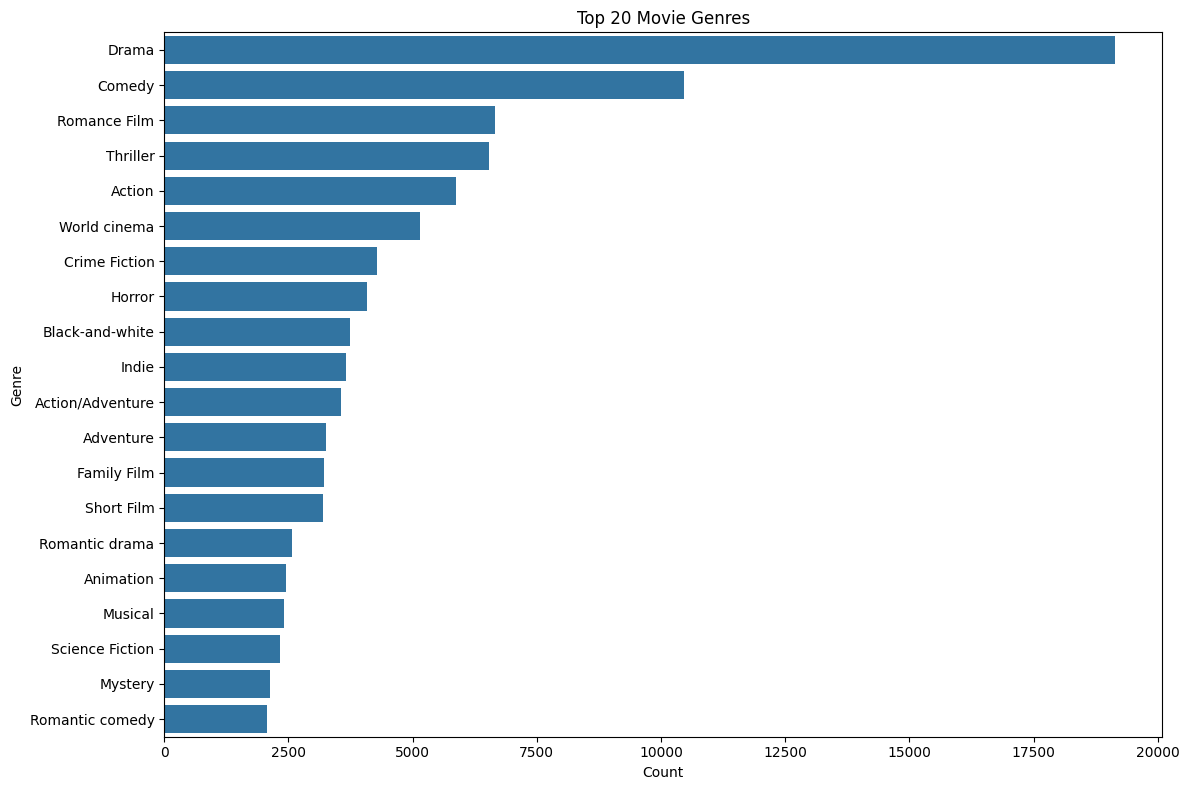

In [3]:

# Define paths to dataset files
data_dir = '/home/muhammad-usman/AI_Project/MovieSummaries'
movie_metadata_path = os.path.join(data_dir, 'movie.metadata.tsv')
plot_summaries_path = os.path.join(data_dir, 'plot_summaries.txt')

# Load movie metadata
movie_metadata = pd.read_csv(movie_metadata_path, sep='\t', header=None)
movie_metadata.columns = ['movie_id', 'IMDb_URL', 'title', 'release_date', 'budget', 'runtime', 'language', 'country', 'genre']
# Load plot summaries
plot_summaries = pd.read_csv(plot_summaries_path, sep='\t', header=None)
plot_summaries.columns = ['movie_id', 'summary']

# Convert movie_id to string for consistent joining
movie_metadata['movie_id'] = movie_metadata['movie_id'].astype(str)
plot_summaries['movie_id'] = plot_summaries['movie_id'].astype(str)

# Merge datasets on movie_id
movies_df = pd.merge(movie_metadata[['movie_id', 'title', 'genre']], 
                     plot_summaries, on='movie_id', how='inner')

# Extract genres from the JSON-like format
def extract_genres(genre_json):
    try:
        # Convert string representation of dictionary to actual dictionary
        import ast
        genre_dict = ast.literal_eval(genre_json)
        return list(genre_dict.values())
    except:
        return []

movies_df['genres'] = movies_df['genre'].apply(extract_genres)

# Keep only movies with non-empty genres and summaries
movies_df = movies_df[movies_df['genres'].map(len) > 0]
movies_df = movies_df[movies_df['summary'].str.len() > 10]

# Display basic stats
print(f"Total number of movies: {len(movies_df)}")
print(f"Number of unique genres: {len(set([genre for genres in movies_df['genres'] for genre in genres]))}")
print("Sample movie entry:")
print(movies_df.iloc[0])

# Explore genre distribution
all_genres = [genre for genres in movies_df['genres'] for genre in genres]
genre_counts = pd.Series(all_genres).value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values[:20], y=genre_counts.index[:20])
plt.title('Top 20 Movie Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

## Limiting Genres

In [4]:
movies_df.head()

,movie_id,title,genre,summary,genres
0,975900,Ghosts of Mars,"{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science...","Set in the second half of the 22nd century, th...","[Thriller, Science Fiction, Horror, Adventure,..."
1,9363483,White Of The Eye,"{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic...",A series of murders of rich young women throug...,"[Thriller, Erotic thriller, Psychological thri..."
2,261236,A Woman in Flames,"{""/m/07s9rl0"": ""Drama""}","Eva, an upper class housewife, becomes frustra...",[Drama]
3,18998739,The Sorcerer's Apprentice,"{""/m/0hqxf"": ""Family Film"", ""/m/01hmnh"": ""Fant...","Every hundred years, the evil Morgana returns...","[Family Film, Fantasy, Adventure, World cinema]"
4,6631279,Little city,"{""/m/06cvj"": ""Romantic comedy"", ""/m/0hj3n0w"": ...","Adam, a San Francisco-based artist who works a...","[Romantic comedy, Ensemble Film, Comedy-drama,..."


In [5]:
work_data = movies_df
work_data = work_data.drop(['movie_id', 'genre', 'title'], axis=1)


In [6]:
work_data.head()

,summary,genres
0,"Set in the second half of the 22nd century, th...","[Thriller, Science Fiction, Horror, Adventure,..."
1,A series of murders of rich young women throug...,"[Thriller, Erotic thriller, Psychological thri..."
2,"Eva, an upper class housewife, becomes frustra...",[Drama]
3,"Every hundred years, the evil Morgana returns...","[Family Film, Fantasy, Adventure, World cinema]"
4,"Adam, a San Francisco-based artist who works a...","[Romantic comedy, Ensemble Film, Comedy-drama,..."


In [7]:
from collections import Counter


all_genres = work_data['genres'].explode()
genre_counts = Counter(all_genres)

top_20_genres = [genre for genre, count in genre_counts.most_common()]

def has_top_genre(genres):
    return any(genre in top_20_genres for genre in genres)

num_movies_with_top_genres = work_data['genres'].apply(has_top_genre).sum()

print(f"Number of movies that include at least one of the top 20 genres: {num_movies_with_top_genres}")

Number of movies that include at least one of the top 20 genres: 41793


In [8]:
exploded = work_data.explode('genres')

# Count the number of movies per genre
genre_movie_counts = exploded['genres'].value_counts()

# Filter to only include genres with more than 1000 movies
popular_genres = genre_movie_counts[genre_movie_counts > 1000]

print(popular_genres)


genres
Drama                     19134
Comedy                    10467
Romance Film               6666
Thriller                   6530
Action                     5868
World cinema               5153
Crime Fiction              4275
Horror                     4082
Black-and-white            3731
Indie                      3668
Action/Adventure           3553
Adventure                  3248
Family Film                3219
Short Film                 3192
Romantic drama             2572
Animation                  2441
Musical                    2414
Science Fiction            2339
Mystery                    2119
Romantic comedy            2075
Fantasy                    2012
Comedy film                1778
Crime Thriller             1682
War film                   1556
Period piece               1321
Japanese Movies            1290
Comedy-drama               1261
Film adaptation            1225
Documentary                1213
Silent film                1199
Psychological thriller     1138
B

In [9]:
exploded = work_data.explode('genres')

# Count the number of movies per genre
genre_movie_counts = exploded['genres'].value_counts()

# Count how many genres have more than 100 movies
num_genres_over_100 = (genre_movie_counts > 1000).sum()

print(f"Number of genres with more than 1000 movies: {num_genres_over_100}")


Number of genres with more than 1000 movies: 33


In [10]:
# Step 1: Explode the genres column
exploded = work_data.explode('genres')

# Step 2: Get the top 33 genres
top_33_genres = exploded['genres'].value_counts().head(33).index

# Step 3: Filter rows where genre is in top 33
filtered = exploded[exploded['genres'].isin(top_33_genres)]

# Step 4: Count unique movies (assuming index or a column like 'movie_id' identifies a movie)
# If each row in `work_data` is one movie, use the original index:
unique_movie_count = filtered.index.nunique()

print(f"Number of unique movies with at least one of the top 33 genres: {unique_movie_count}")


Number of unique movies with at least one of the top 33 genres: 41122


In [11]:
# Step 1: Explode the genres column to count genres across all movies
exploded = work_data.explode('genres')

# Step 2: Count occurrences of each genre
genre_counts = exploded['genres'].value_counts()

# Step 3: Keep only genres with 1000 or more movies
popular_genres = genre_counts[genre_counts >= 1000].index

# Step 4: Filter exploded DataFrame to keep only popular genres
filtered = exploded[exploded['genres'].isin(popular_genres)]

# Step 5: Group back to restore the original list structure
work_data['genres'] = filtered.groupby(filtered.index)['genres'].apply(list)

# Step 6: (Optional) Drop movies that now have no genres left
# Step 6: Drop movies where 'genres' is NaN or the list is empty
work_data = work_data[work_data['genres'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

# Done


In [12]:
exploded = work_data.explode('genres')

# Count the number of movies per genre
genre_movie_counts = exploded['genres'].value_counts()

# Filter to only include genres with more than 1000 movies
popular_genres = genre_movie_counts[genre_movie_counts > 100]

print(popular_genres)


genres
Drama                     19134
Comedy                    10467
Romance Film               6666
Thriller                   6530
Action                     5868
World cinema               5153
Crime Fiction              4275
Horror                     4082
Black-and-white            3731
Indie                      3668
Action/Adventure           3553
Adventure                  3248
Family Film                3219
Short Film                 3192
Romantic drama             2572
Animation                  2441
Musical                    2414
Science Fiction            2339
Mystery                    2119
Romantic comedy            2075
Fantasy                    2012
Comedy film                1778
Crime Thriller             1682
War film                   1556
Period piece               1321
Japanese Movies            1290
Comedy-drama               1261
Film adaptation            1225
Documentary                1213
Silent film                1199
Psychological thriller     1138
B

In [13]:
# Flatten the genres into a single list and get unique values
unique_genres = pd.Series([genre for sublist in work_data['genres'] if isinstance(sublist, list) for genre in sublist]).unique()

# Display the genres
print(f"Remaining genres ({len(unique_genres)} total):")
print(unique_genres)


Remaining genres (33 total):
['Thriller' 'Science Fiction' 'Horror' 'Adventure' 'Action'
 'Psychological thriller' 'Drama' 'Family Film' 'Fantasy' 'World cinema'
 'Romantic comedy' 'Comedy-drama' 'Comedy' 'Romantic drama' 'Romance Film'
 'War film' 'Period piece' 'Film adaptation' 'Animation' 'Short Film'
 'Musical' 'Indie' 'Crime Fiction' 'Bollywood' 'Action/Adventure'
 'Black-and-white' 'Documentary' 'Western' 'Mystery' 'Crime Thriller'
 'Japanese Movies' 'Comedy film' 'Silent film']


In [14]:
work_data.head(5)

,summary,genres
0,"Set in the second half of the 22nd century, th...","[Thriller, Science Fiction, Horror, Adventure,..."
1,A series of murders of rich young women throug...,"[Thriller, Psychological thriller]"
2,"Eva, an upper class housewife, becomes frustra...",[Drama]
3,"Every hundred years, the evil Morgana returns...","[Family Film, Fantasy, Adventure, World cinema]"
4,"Adam, a San Francisco-based artist who works a...","[Romantic comedy, Comedy-drama, Drama, Comedy,..."


In [15]:
movies_df.head(5)

,movie_id,title,genre,summary,genres
0,975900,Ghosts of Mars,"{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science...","Set in the second half of the 22nd century, th...","[Thriller, Science Fiction, Horror, Adventure,..."
1,9363483,White Of The Eye,"{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic...",A series of murders of rich young women throug...,"[Thriller, Erotic thriller, Psychological thri..."
2,261236,A Woman in Flames,"{""/m/07s9rl0"": ""Drama""}","Eva, an upper class housewife, becomes frustra...",[Drama]
3,18998739,The Sorcerer's Apprentice,"{""/m/0hqxf"": ""Family Film"", ""/m/01hmnh"": ""Fant...","Every hundred years, the evil Morgana returns...","[Family Film, Fantasy, Adventure, World cinema]"
4,6631279,Little city,"{""/m/06cvj"": ""Romantic comedy"", ""/m/0hj3n0w"": ...","Adam, a San Francisco-based artist who works a...","[Romantic comedy, Ensemble Film, Comedy-drama,..."


In [16]:
work_data.head(2)

# work_data = work_data.drop(['summary'], axis=1)

,summary,genres
0,"Set in the second half of the 22nd century, th...","[Thriller, Science Fiction, Horror, Adventure,..."
1,A series of murders of rich young women throug...,"[Thriller, Psychological thriller]"


In [ ]:
work_data.to_tsv

AttributeError: 'DataFrame' object has no attribute 'to_txt'

## Text Processing

In [18]:
# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize
    tokens = nltk.word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Rejoin tokens into a single string
    return ' '.join(tokens)

# Apply preprocessing to all summaries
print("Preprocessing movie summaries...")
work_data['processed_summary'] = work_data['summary'].apply(preprocess_text)

# Encode the genre labels using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(work_data['genres'])
genre_labels = mlb.classes_
print(f"Genre labels: {genre_labels}")

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    work_data['processed_summary'], 
    genre_encoded,
    test_size=0.2, 
    random_state=42,
    stratify=np.argmax(genre_encoded, axis=1)  # Stratify by the most common genre for each movie
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# TF-IDF feature extraction
print("Extracting TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# For neural networks, prepare tokenized sequences
print("Preparing text sequences for neural networks...")
max_words = 10000  # Maximum vocabulary size
max_seq_length = 200  # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_seq_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_seq_length)

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")
print(f"Sequence feature matrix shape: {X_train_pad.shape}")

Preprocessing movie summaries...
Genre labels: ['Action' 'Action/Adventure' 'Adventure' 'Animation' 'Black-and-white'
 'Bollywood' 'Comedy' 'Comedy film' 'Comedy-drama' 'Crime Fiction'
 'Crime Thriller' 'Documentary' 'Drama' 'Family Film' 'Fantasy'
 'Film adaptation' 'Horror' 'Indie' 'Japanese Movies' 'Musical' 'Mystery'
 'Period piece' 'Psychological thriller' 'Romance Film' 'Romantic comedy'
 'Romantic drama' 'Science Fiction' 'Short Film' 'Silent film' 'Thriller'
 'War film' 'Western' 'World cinema']
Training set size: 32897
Testing set size: 8225
Extracting TF-IDF features...
Preparing text sequences for neural networks...
TF-IDF feature matrix shape: (32897, 5000)
Sequence feature matrix shape: (32897, 200)


## Model Evaluation and Models of ML


Training Logistic Regression model...


/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr


===== Logistic Regression Evaluation =====
Accuracy: 0.1127
Micro-average - Precision: 0.6939, Recall: 0.2813, F1: 0.4003
Macro-average - Precision: 0.6254, Recall: 0.1783, F1: 0.2531

Classification Report:
                        precision    recall  f1-score   support

                Action       0.66      0.30      0.41      1174
      Action/Adventure       0.59      0.17      0.26       720
             Adventure       0.75      0.19      0.31       641
             Animation       0.77      0.35      0.48       473
       Black-and-white       0.81      0.11      0.20       747
             Bollywood       0.46      0.06      0.11       213
                Comedy       0.67      0.34      0.45      2132
           Comedy film       0.38      0.01      0.02       358
          Comedy-drama       0.00      0.00      0.00       257
         Crime Fiction       0.61      0.21      0.32       881
        Crime Thriller       0.50      0.04      0.07       339
           Documentary

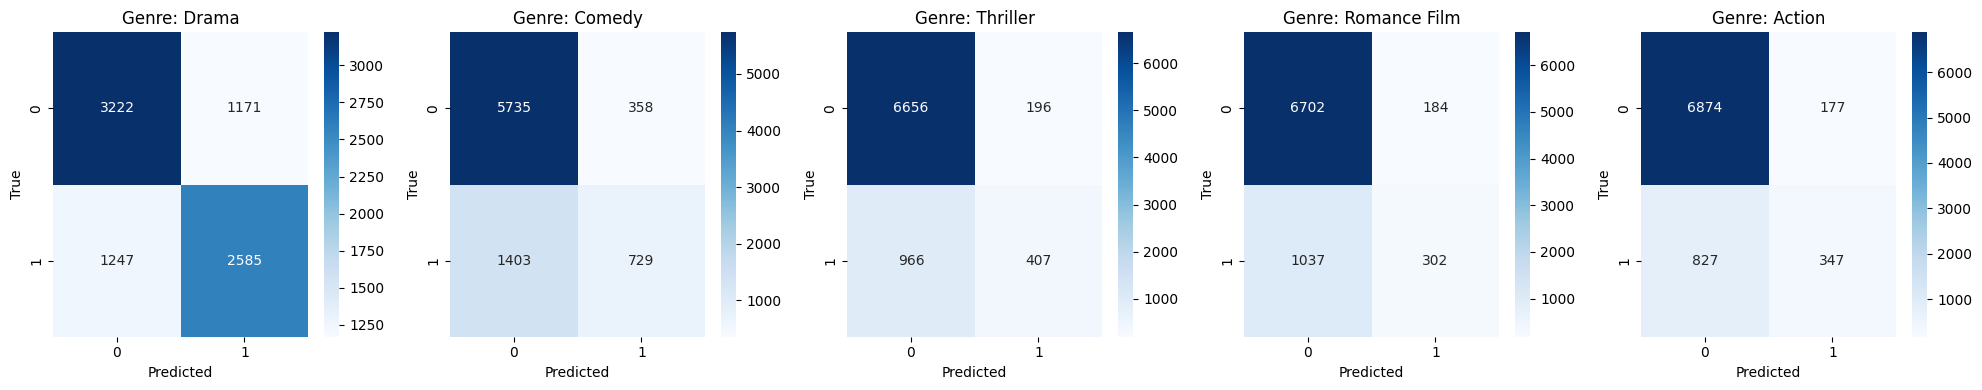


Training Random Forest model...


/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr


===== Random Forest Evaluation =====
Accuracy: 0.0885
Micro-average - Precision: 0.7097, Recall: 0.1555, F1: 0.2551
Macro-average - Precision: 0.4960, Recall: 0.0695, F1: 0.1045

Classification Report:
                        precision    recall  f1-score   support

                Action       0.78      0.07      0.13      1174
      Action/Adventure       1.00      0.01      0.01       720
             Adventure       0.60      0.00      0.01       641
             Animation       0.84      0.18      0.30       473
       Black-and-white       0.94      0.08      0.15       747
             Bollywood       0.00      0.00      0.00       213
                Comedy       0.80      0.09      0.15      2132
           Comedy film       0.00      0.00      0.00       358
          Comedy-drama       0.00      0.00      0.00       257
         Crime Fiction       0.73      0.02      0.04       881
        Crime Thriller       0.00      0.00      0.00       339
           Documentary      

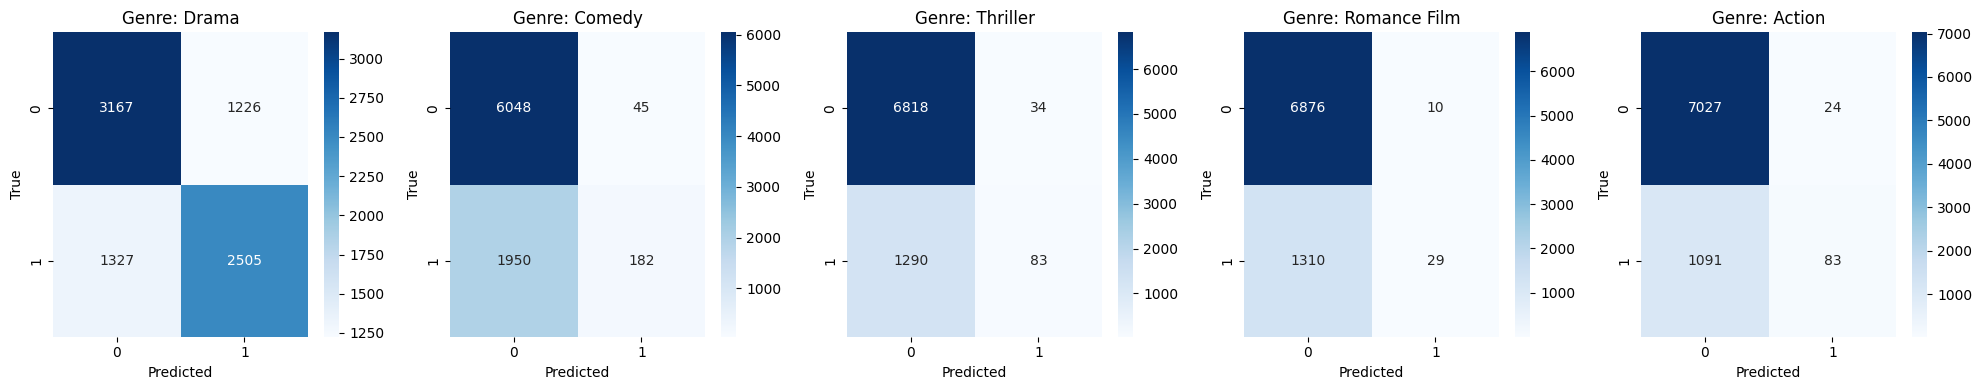

In [21]:
# Function to evaluate and display results
def evaluate_model(y_pred, y_true, model_name):
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision_micro = precision_score(y_true, y_pred, average='micro')
    recall_micro = recall_score(y_true, y_pred, average='micro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    
    precision_macro = precision_score(y_true, y_pred, average='macro')
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    # Print metrics
    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Micro-average - Precision: {precision_micro:.4f}, Recall: {recall_micro:.4f}, F1: {f1_micro:.4f}")
    print(f"Macro-average - Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
    
    # Classification report for detailed per-class metrics
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=genre_labels))
    
    # Plot confusion matrices for the top 5 genres
    top_genres_idx = np.argsort(-np.sum(y_true, axis=0))[:5]
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i, idx in enumerate(top_genres_idx):
        cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'Genre: {genre_labels[idx]}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy, f1_micro, f1_macro

# 1. Logistic Regression (One-vs-Rest)
print("\nTraining Logistic Regression model...")
lr_model = MultiOutputClassifier(LogisticRegression(max_iter=1000, C=1.0))
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_accuracy, lr_f1_micro, lr_f1_macro = evaluate_model(lr_pred, y_test, "Logistic Regression")

# 2. Random Forest
print("\nTraining Random Forest model...")
rf_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)
rf_accuracy, rf_f1_micro, rf_f1_macro = evaluate_model(rf_pred, y_test, "Random Forest")

## DL Model


Training Multilayer Perceptron model...


/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-06 00:33:43.199600: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-05-06 00:33:58.952369: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 592140000 exceeds 10% of free system memory.


Epoch 1/10
461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2134 - loss: 0.3412

2025-05-06 00:34:20.771384: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 65800000 exceeds 10% of free system memory.


463/463 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.2136 - loss: 0.3408 - val_accuracy: 0.3271 - val_loss: 0.2061
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3361 - loss: 0.2055 - val_accuracy: 0.3596 - val_loss: 0.1903
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3774 - loss: 0.1852 - val_accuracy: 0.3653 - val_loss: 0.1857
Epoch 4/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3922 - loss: 0.1728 - val_accuracy: 0.3723 - val_loss: 0.1848
Epoch 5/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.4067 - loss: 0.1631 - val_accuracy: 0.3644 - val_loss: 0.1852
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.4248 - loss: 0.1545 - val_accuracy: 0.3571 - val_loss: 0.1870
Epoch 7/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.4241 - loss: 0.1470 - val_accuracy: 0.3608 - val_loss: 0.1887
  1/258 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step

2025-05-06 00:35:32.678033: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 164500000 exceeds 10% of free system memory.


258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr


===== Multilayer Perceptron Evaluation =====
Accuracy: 0.1232
Micro-average - Precision: 0.6798, Recall: 0.3282, F1: 0.4427
Macro-average - Precision: 0.5366, Recall: 0.2285, F1: 0.2953

Classification Report:
                        precision    recall  f1-score   support

                Action       0.65      0.37      0.47      1174
      Action/Adventure       0.54      0.24      0.33       720
             Adventure       0.65      0.25      0.36       641
             Animation       0.71      0.49      0.58       473
       Black-and-white       0.68      0.14      0.24       747
             Bollywood       0.42      0.08      0.13       213
                Comedy       0.67      0.37      0.48      2132
           Comedy film       0.00      0.00      0.00       358
          Comedy-drama       0.00      0.00      0.00       257
         Crime Fiction       0.60      0.34      0.44       881
        Crime Thriller       0.44      0.15      0.22       339
           Documenta

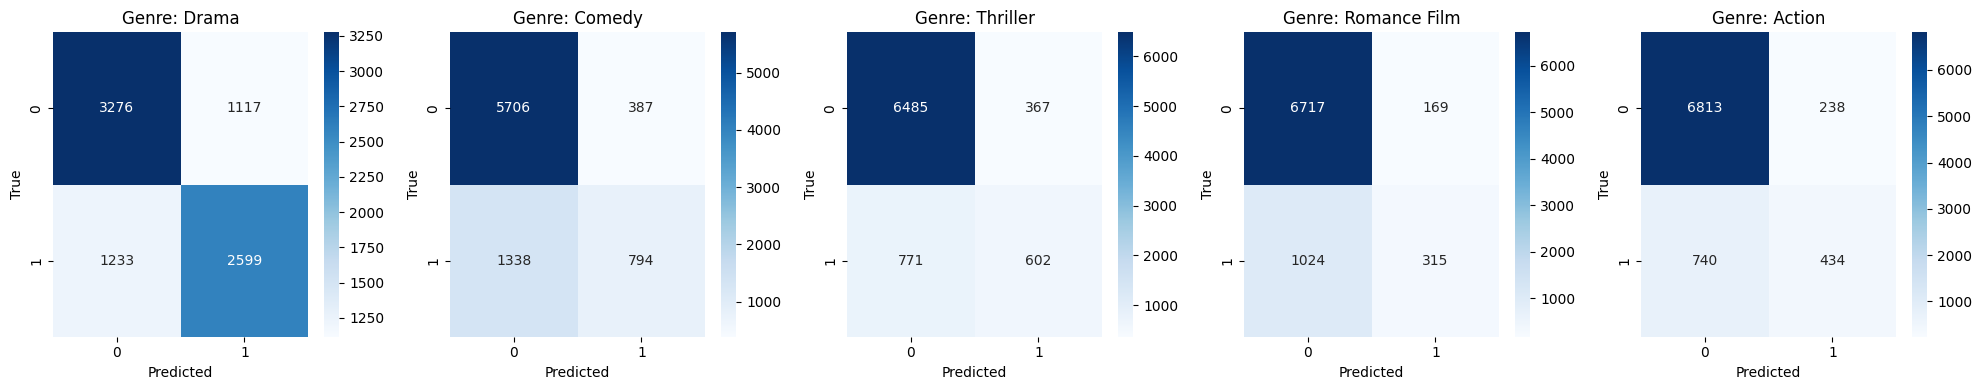


Training Bidirectional LSTM model...


/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5


2025-05-06 00:35:39.199935: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 23685600 exceeds 10% of free system memory.
2025-05-06 00:35:42.560616: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 59359200 exceeds 10% of free system memory.


926/926 ━━━━━━━━━━━━━━━━━━━━ 435s 461ms/step - accuracy: 0.1915 - loss: 0.3021 - val_accuracy: 0.2182 - val_loss: 0.2464
Epoch 2/5
926/926 ━━━━━━━━━━━━━━━━━━━━ 387s 417ms/step - accuracy: 0.2332 - loss: 0.2452 - val_accuracy: 0.2331 - val_loss: 0.2376
Epoch 3/5
926/926 ━━━━━━━━━━━━━━━━━━━━ 360s 389ms/step - accuracy: 0.2346 - loss: 0.2370 - val_accuracy: 0.2362 - val_loss: 0.2281
Epoch 4/5
926/926 ━━━━━━━━━━━━━━━━━━━━ 331s 357ms/step - accuracy: 0.2492 - loss: 0.2209 - val_accuracy: 0.2775 - val_loss: 0.2157
Epoch 5/5
926/926 ━━━━━━━━━━━━━━━━━━━━ 326s 352ms/step - accuracy: 0.2965 - loss: 0.2048 - val_accuracy: 0.3100 - val_loss: 0.2114
258/258 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step


/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/muhammad-usman/AI_Project/AI_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr


===== Bidirectional LSTM Evaluation =====
Accuracy: 0.0902
Micro-average - Precision: 0.6053, Recall: 0.2623, F1: 0.3660
Macro-average - Precision: 0.2641, Recall: 0.1304, F1: 0.1564

Classification Report:
                        precision    recall  f1-score   support

                Action       0.53      0.41      0.46      1174
      Action/Adventure       0.53      0.16      0.25       720
             Adventure       0.50      0.18      0.27       641
             Animation       0.57      0.51      0.54       473
       Black-and-white       0.00      0.00      0.00       747
             Bollywood       0.00      0.00      0.00       213
                Comedy       0.58      0.14      0.22      2132
           Comedy film       0.00      0.00      0.00       358
          Comedy-drama       0.00      0.00      0.00       257
         Crime Fiction       0.43      0.07      0.12       881
        Crime Thriller       0.00      0.00      0.00       339
           Documentary 

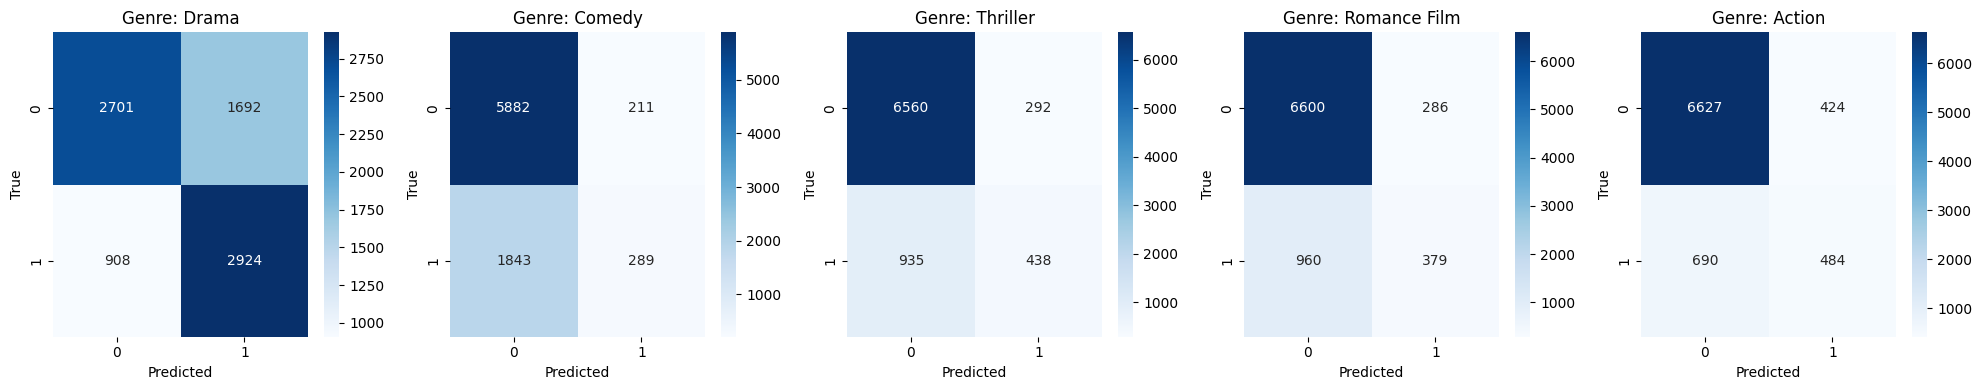

In [22]:
# 3. Simple MLP with TF-IDF Features
print("\nTraining Multilayer Perceptron model...")
# Convert sparse matrix to dense for Keras
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_tfidf_dense.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='sigmoid')
])

mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

mlp_history = mlp_model.fit(
    X_train_tfidf_dense, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

mlp_pred = (mlp_model.predict(X_test_tfidf_dense) > 0.5).astype(int)
mlp_accuracy, mlp_f1_micro, mlp_f1_macro = evaluate_model(mlp_pred, y_test, "Multilayer Perceptron")

# 4. Bidirectional LSTM
print("\nTraining Bidirectional LSTM model...")
# Calculate total number of words in vocabulary
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100

lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_seq_length),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y_train.shape[1], activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype(int)
lstm_accuracy, lstm_f1_micro, lstm_f1_macro = evaluate_model(lstm_pred, y_test, "Bidirectional LSTM")

## Comparoisons Models

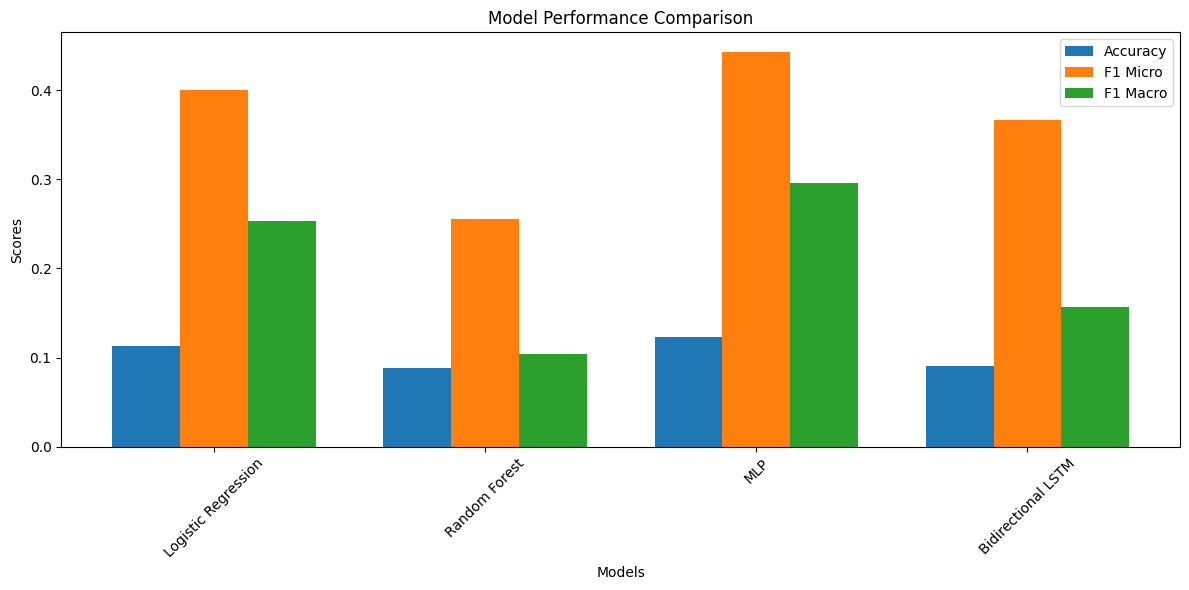


Best performing model based on F1 macro score: MLP


In [23]:
# Compare all models
models = ['Logistic Regression', 'Random Forest', 'MLP', 'Bidirectional LSTM']
accuracies = [lr_accuracy, rf_accuracy, mlp_accuracy, lstm_accuracy]
f1_micro_scores = [lr_f1_micro, rf_f1_micro, mlp_f1_micro, lstm_f1_micro]
f1_macro_scores = [lr_f1_macro, rf_f1_macro, mlp_f1_macro, lstm_f1_macro]

# Create comparison plot
plt.figure(figsize=(12, 6))

x = np.arange(len(models))
width = 0.25

plt.bar(x - width, accuracies, width, label='Accuracy')
plt.bar(x, f1_micro_scores, width, label='F1 Micro')
plt.bar(x + width, f1_macro_scores, width, label='F1 Macro')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Select the best model based on F1 macro score (handles class imbalance better)
best_model_idx = np.argmax(f1_macro_scores)
best_model_name = models[best_model_idx]
print(f"\nBest performing model based on F1 macro score: {best_model_name}")

# Function to save the final selected model
def save_best_model():
    if best_model_name == 'Logistic Regression':
        import pickle
        with open('genre_prediction_model.pkl', 'wb') as f:
            pickle.dump({
                'model': lr_model,
                'vectorizer': tfidf_vectorizer,
                'mlb': mlb,
                'preprocess_fn': preprocess_text
            }, f)
    elif best_model_name == 'Random Forest':
        import pickle
        with open('genre_prediction_model.pkl', 'wb') as f:
            pickle.dump({
                'model': rf_model,
                'vectorizer': tfidf_vectorizer,
                'mlb': mlb,
                'preprocess_fn': preprocess_text
            }, f)
    elif best_model_name == 'MLP':
        mlp_model.save('genre_prediction_model')
        import pickle
        with open('genre_prediction_preprocessing.pkl', 'wb') as f:
            pickle.dump({
                'vectorizer': tfidf_vectorizer,
                'mlb': mlb,
                'preprocess_fn': preprocess_text
            }, f)
    else:  # LSTM
        lstm_model.save('genre_prediction_model')
        import pickle
        with open('genre_prediction_preprocessing.pkl', 'wb') as f:
            pickle.dump({
                'tokenizer': tokenizer,
                'max_seq_length': max_seq_length,
                'mlb': mlb,
                'preprocess_fn': preprocess_text
            }, f)
    
    print(f"Best model '{best_model_name}' saved successfully!")

# Uncomment this to save the model
# save_best_model()

## Transformer BAsed 

In [31]:
# Import necessary libraries for transformers
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from tqdm.auto import tqdm

### PIPELINE

In [26]:
def create_transformer_pipeline(model_name="distilbert-base-uncased", num_labels=None):
    """Create a complete transformer pipeline for multi-label classification"""
    
    print(f"Setting up transformer pipeline with {model_name}...")
    
    # Initialize tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Initialize model for multi-label classification
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        problem_type="multi_label_classification"
    )
    
    return tokenizer, model

def compute_metrics(eval_pred):
    """Compute metrics for multi-label classification"""
    predictions, labels = eval_pred
    predictions = (predictions > 0).astype(int)  # Apply sigmoid + threshold
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    f1_micro = f1_score(labels, predictions, average='micro')
    f1_macro = f1_score(labels, predictions, average='macro')
    precision_micro = precision_score(labels, predictions, average='micro')
    recall_micro = recall_score(labels, predictions, average='micro')
    
    return {
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro
    }

### Training and Evaluation

In [27]:
def train_transformer_model(X_train, y_train, X_val, y_val, tokenizer, model, genre_labels,
                           batch_size=8, learning_rate=2e-5, epochs=3, max_length=256):
    """
    Train a transformer model for multi-label classification
    
    Args:
        X_train: Training text data
        y_train: Training labels (multi-hot encoded)
        X_val: Validation text data
        y_val: Validation labels (multi-hot encoded)
        tokenizer: Pre-trained tokenizer
        model: Pre-trained model
        genre_labels: List of genre labels
        batch_size: Batch size for training
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs
        max_length: Maximum sequence length
    """
    # Create datasets
    train_dataset = MovieGenreDataset(X_train, y_train, tokenizer, max_length)
    val_dataset = MovieGenreDataset(X_val, y_val, tokenizer, max_length)
    
    # Define training arguments
    training_args = TrainingArguments(
        output_dir='./transformer_model_checkpoints',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./transformer_logs',
        logging_steps=10,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=True,  # Use mixed precision training if GPU available
    )
    
    # Initialize trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStopping(early_stopping_patience=3)]
    )
    
    # Train the model
    print("Training transformer model...")
    trainer.train()
    
    # Evaluate the model
    print("Evaluating model on validation set...")
    eval_results = trainer.evaluate()
    print(f"Validation results: {eval_results}")
    
    return trainer, model

In [28]:
def predict_with_transformer(text, tokenizer, model, genre_labels, max_length=256):
    """
    Make predictions using the transformer model
    
    Args:
        text: Input text to classify
        tokenizer: Trained tokenizer
        model: Trained model
        genre_labels: List of genre labels
        max_length: Maximum sequence length
    
    Returns:
        List of (genre, confidence) tuples
    """
    # Tokenize input
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        padding='max_length',
        return_tensors='pt'
    )
    
    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Set model to evaluation mode
    model.eval()
    
    # Make prediction
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(logits).cpu().numpy()[0]
    
    # Get predictions (apply threshold)
    predictions = (probs > 0.5).astype(int)
    
    # Create list of (genre, confidence) for predicted genres
    results = []
    for i, pred in enumerate(predictions):
        if pred == 1:
            results.append((genre_labels[i], float(probs[i])))
    
    # Sort by confidence
    results.sort(key=lambda x: x[1], reverse=True)
    
    return results

In [29]:
def transformer_pipeline(movies_df, test_size=0.2, random_state=42):
    """
    Complete pipeline for transformer-based multi-label genre classification
    
    Args:
        movies_df: DataFrame containing processed movie summaries and genres
        test_size: Proportion of data to use for testing
        random_state: Random seed for reproducibility
    
    Returns:
        Trained model, tokenizer, and binarizer for genre labels
    """
    print("Starting transformer pipeline...")
    
    # Prepare labels
    mlb = MultiLabelBinarizer()
    genre_encoded = mlb.fit_transform(movies_df['genres'])
    genre_labels = mlb.classes_
    print(f"Number of unique genres: {len(genre_labels)}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        movies_df['processed_summary'], 
        genre_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=np.argmax(genre_encoded, axis=1)  # Stratify by most common genre
    )
    
    # Further split training data to create validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=random_state
    )
    
    print(f"Training set: {len(X_train)}, Validation set: {len(X_val)}, Test set: {len(X_test)}")
    
    # Initialize tokenizer and model
    model_name = "distilbert-base-uncased"  # Smaller model that works well for fine-tuning
    tokenizer, model = create_transformer_pipeline(model_name, num_labels=len(genre_labels))
    
    # Train the model
    trainer, model = train_transformer_model(
        X_train, y_train, X_val, y_val, tokenizer, model, genre_labels,
        batch_size=8, learning_rate=2e-5, epochs=3
    )
    
    # Evaluate on test set
    print("Evaluating model on test set...")
    
    # Create test dataset
    test_dataset = MovieGenreDataset(X_test, y_test, tokenizer)
    
    # Evaluate using trainer
    test_results = trainer.evaluate(test_dataset)
    print(f"Test results: {test_results}")
    
    # Detailed evaluation with per-class metrics
    all_predictions = []
    model.eval()
    test_dataloader = DataLoader(test_dataset, batch_size=8)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Generating predictions"):
            # Move batch to device
            batch = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            
            # Get predictions
            outputs = model(**batch)
            logits = outputs.logits
            
            # Apply sigmoid for multi-label
            predictions = torch.sigmoid(logits).cpu().numpy()
            predictions = (predictions > 0.5).astype(int)
            
            all_predictions.extend(predictions)
    
    # Convert to numpy array
    all_predictions = np.array(all_predictions)
    
    # Calculate per-class metrics
    for i, genre in enumerate(genre_labels):
        precision = precision_score(y_test[:, i], all_predictions[:, i])
        recall = recall_score(y_test[:, i], all_predictions[:, i])
        f1 = f1_score(y_test[:, i], all_predictions[:, i])
        print(f"{genre}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")
    
    # Save model and tokenizer
    model_save_path = './transformer_model'
    tokenizer.save_pretrained(model_save_path)
    model.save_pretrained(model_save_path)
    print(f"Model and tokenizer saved to {model_save_path}")
    
    return model, tokenizer, mlb

In [30]:
# Example of how to use the complete pipeline
def run_transformer_pipeline(movies_df):
    """Run the complete transformer pipeline and test with an example"""
    
    # Run the pipeline
    model, tokenizer, mlb = transformer_pipeline(movies_df)
    
    # Example prediction
    example_summary = """
    A young hobbit named Frodo is given a powerful ring by his uncle. 
    When he learns it is the One Ring of Power and the evil lord Sauron 
    is searching for it, he must leave his home and embark on a dangerous 
    journey to destroy the ring in the fires of Mount Doom.
    """
    
    # Preprocess summary
    processed_summary = preprocess_text(example_summary)
    
    # Make prediction
    predictions = predict_with_transformer(
        processed_summary, 
        tokenizer, 
        model, 
        mlb.classes_
    )
    
    # Print results
    print("\nPredicted Genres:")
    for genre, confidence in predictions:
        print(f"- {genre}: {confidence:.4f}")
    
    return model, tokenizer, mlb

# Integration with the main system
def transformer_genre_prediction_module(summary):
    """
    Function to be integrated with the Filmception user interface
    using the transformer model
    
    Args:
        summary (str): The movie summary text provided by the user
    
    Returns:
        dict: Dictionary containing predicted genres with confidence scores
    """
    # Load saved model and tokenizer
    model_path = './transformer_model'
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    # Load genre labels
    import pickle
    with open('genre_prediction_preprocessing.pkl', 'rb') as f:
        preprocessing = pickle.load(f)
        mlb = preprocessing['mlb']
        preprocess_fn = preprocessing['preprocess_fn']
    
    # Preprocess the summary
    processed_summary = preprocess_fn(summary)
    
    # Make prediction
    predictions = predict_with_transformer(
        processed_summary,
        tokenizer,
        model,
        mlb.classes_
    )
    
    # Format results for display
    results = {
        'predicted_genres': [genre for genre, _ in predictions],
        'confidence_scores': {genre: float(conf) for genre, conf in predictions},
        'model_used': 'Transformer (DistilBERT)'
    }
    
    return results